# Data Analysis Midterm Exam

## Import some Librairies

In [21]:
!pip install statsmodels

In [22]:
import numpy as np
import pandas as pd
import seaborn as sb
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Load Datas

In [23]:
covid_df = pd.read_csv('covid_cases_ivory.csv', parse_dates=['date'])
sales_df = pd.read_csv('sales_cocacola_ivory.csv', parse_dates=['date'])

In [24]:
# Display first few rows of covid_df
covid_df.head()

,date,new_cases,new_deaths,total_cases,total_deaths
0,2020-01-01,28,2,28,2
1,2020-01-02,34,0,62,2
2,2020-01-03,28,2,90,4
3,2020-01-04,31,0,121,4
4,2020-01-05,35,1,156,5


In [25]:
sales_df.head()

,date,product,channel,region,units_sold,revenue,price_per_unit
0,2019-01-31,Coke,Retail,Abidjan,4974,5435.58,1.09
1,2019-01-31,Coke,Wholesale,Bouaké,5019,4215.91,0.84
2,2019-01-31,Coke,Ontrade,Yamoussoukro,5090,5513.64,1.08
3,2019-01-31,Coke,Delivery,Yamoussoukro,4851,5701.97,1.18
4,2019-01-31,Fanta,Retail,Yamoussoukro,4927,4541.20,0.92


In [26]:
# Display useful information of sales_df
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            720 non-null    datetime64[ns]
 1   product         720 non-null    object        
 2   channel         720 non-null    object        
 3   region          720 non-null    object        
 4   units_sold      720 non-null    int64         
 5   revenue         720 non-null    float64       
 6   price_per_unit  720 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 39.5+ KB


In [27]:
# Display useful information of covid_df
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          731 non-null    datetime64[ns]
 1   new_cases     731 non-null    int64         
 2   new_deaths    731 non-null    int64         
 3   total_cases   731 non-null    int64         
 4   total_deaths  731 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 28.7 KB


## Aggragate of monthly sales & Covid 19 Data

In [28]:
sales_df['month'] = sales_df['date'].dt.to_period('M').dt.to_timestamp()
monthly_sales = sales_df.groupby(['month','product']).agg({
    'units_sold':'sum',
    'revenue':'sum'
}).reset_index()

monthly_total_sales = monthly_sales.groupby('month').agg({'units_sold':'sum','revenue':'sum'}).reset_index()
monthly_total_sales = monthly_total_sales.sort_values('month')

covid_df['month'] = covid_df['date'].dt.to_period('M').dt.to_timestamp()
monthly_covid = covid_df.groupby('month').agg({'new_cases':'sum'}).reset_index()
total_deaths = covid_df.groupby('month').agg({'new_deaths':'sum'}).reset_index()


monthly_sales.head()
monthly_covid.head()

,month,new_cases
0,2020-01-01,914
1,2020-02-01,920
2,2020-03-01,873
3,2020-04-01,3648
4,2020-05-01,3856


## Plot Coca-cola sales timeline

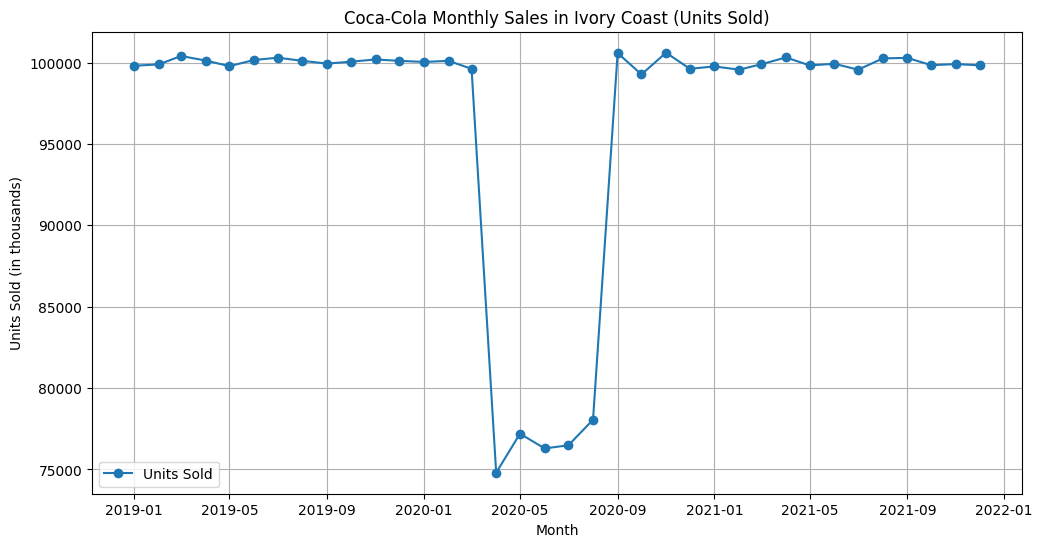

In [29]:
plt.figure(figsize=(12,6))
plt.plot(monthly_total_sales['month'], monthly_total_sales['units_sold'], marker='o', label='Units Sold')
plt.title('Coca-Cola Monthly Sales in Ivory Coast (Units Sold)')
plt.xlabel('Month')
plt.ylabel('Units Sold (in thousands)')
plt.legend()
plt.grid(True)
plt.show()

## Covid 19 Cases and Death

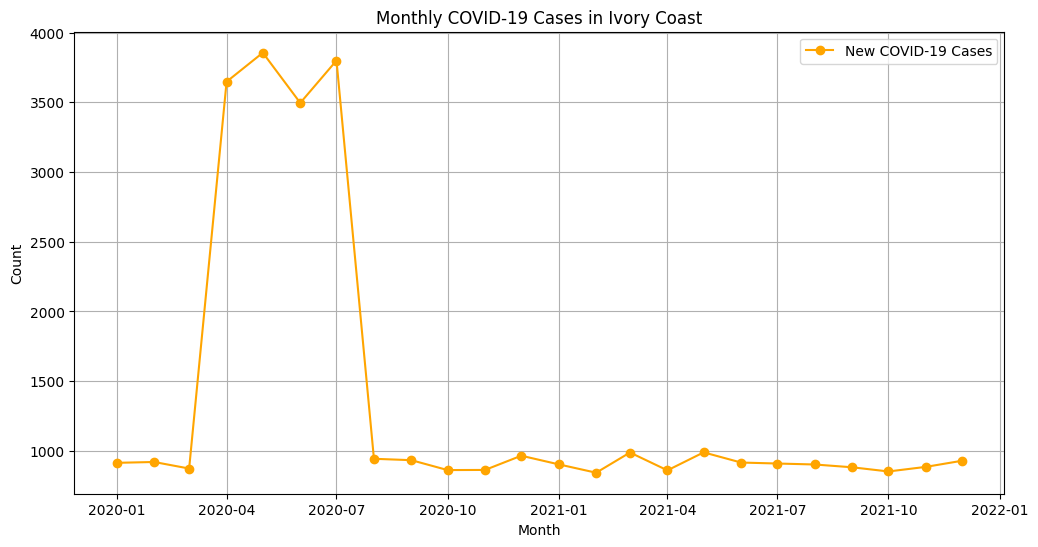

In [30]:
plt.figure(figsize=(12,6))
plt.plot(monthly_covid['month'], monthly_covid['new_cases'], marker='o', color='orange', label='New COVID-19 Cases')
#plt.plot(total_deaths['month'], total_deaths['new_deaths'], marker='x', color='red', label='New COVID-19 Deaths')
plt.title('Monthly COVID-19 Cases in Ivory Coast')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

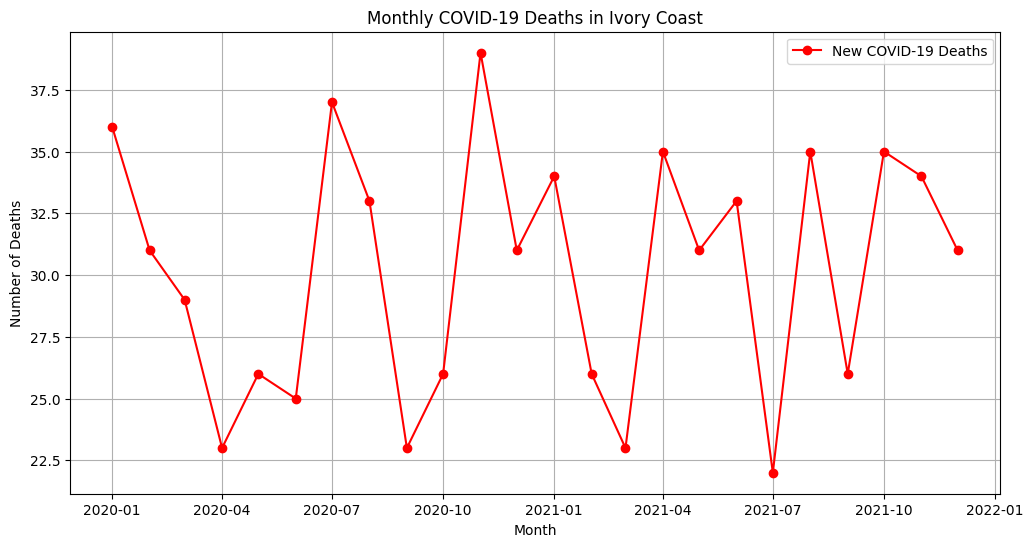

In [31]:
plt.figure(figsize=(12,6))
plt.plot(total_deaths['month'], total_deaths['new_deaths'], marker='o', color='red', label='New COVID-19 Deaths')
plt.title('Monthly COVID-19 Deaths in Ivory Coast')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True)
plt.show()

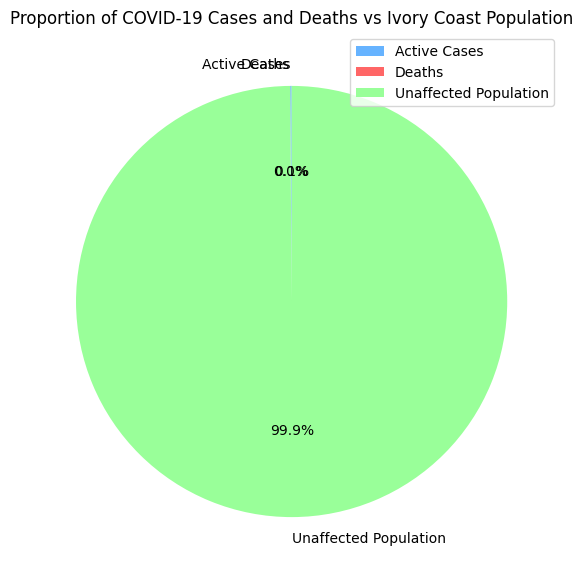

In [32]:
# Total values of deaths, cases, and population
total_cases = covid_df['total_cases'].max()
total_deaths = covid_df['total_deaths'].max()
total_population = 31_165_654  # Approximate population of Ivory Coast according to World Health Organization

# Compute unaffected people
unaffected = total_population - total_cases

# Data for pie chart
labels = ['Active Cases', 'Deaths', 'Unaffected Population']
values = [total_cases - total_deaths, total_deaths, unaffected]

# Plot
plt.figure(figsize=(7,7))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#66b3ff', '#ff6666', '#99ff99'], startangle=90)
plt.title('Proportion of COVID-19 Cases and Deaths vs Ivory Coast Population')
plt.legend()
plt.grid(True)
plt.show()


# Pre-Lockdown vs Lockdown Period

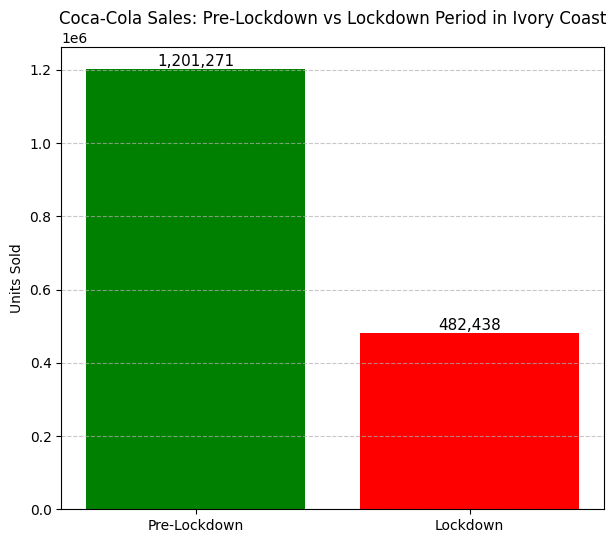

In [33]:
# Separate data by period(pre-lockdown and during lockdown)
pre_lockdown_period = sales_df[(sales_df['date'] >= '2019-03-01') & (sales_df['date'] <= '2020-02-29')]
lockdown_period = sales_df[(sales_df['date'] >= '2020-03-01') & (sales_df['date'] <= '2020-08-31')]

# Total units sold
pre_lockdown_sales = pre_lockdown_period['units_sold'].sum()
lockdown_sales = lockdown_period['units_sold'].sum()

# Labels and values
labels = ['Pre-Lockdown', 'Lockdown']
values = [pre_lockdown_sales, lockdown_sales]

# Plot
plt.figure(figsize=(7,6))
bars = plt.bar(labels, values, color=['green', 'red'])

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=11)

plt.ylabel('Units Sold')
plt.title('Coca-Cola Sales: Pre-Lockdown vs Lockdown Period in Ivory Coast')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Sale Histogram

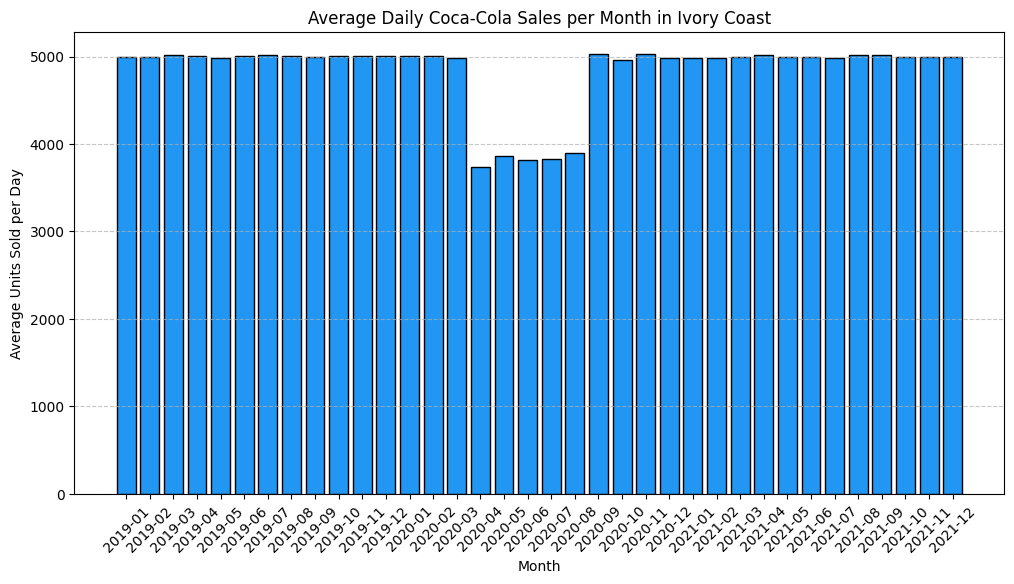

In [34]:
monthly_average_sales = sales_df.groupby(sales_df['date'].dt.to_period('M'))['units_sold'].mean().reset_index()
monthly_average_sales['month'] = monthly_average_sales['date'].astype(str)

plt.figure(figsize=(12,6))
plt.bar(monthly_average_sales['month'], monthly_average_sales['units_sold'], color='#2196F3', edgecolor='black')
plt.title('Average Daily Coca-Cola Sales per Month in Ivory Coast')
plt.xlabel('Month')
plt.ylabel('Average Units Sold per Day')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## How Coca-cola sales were impact ?

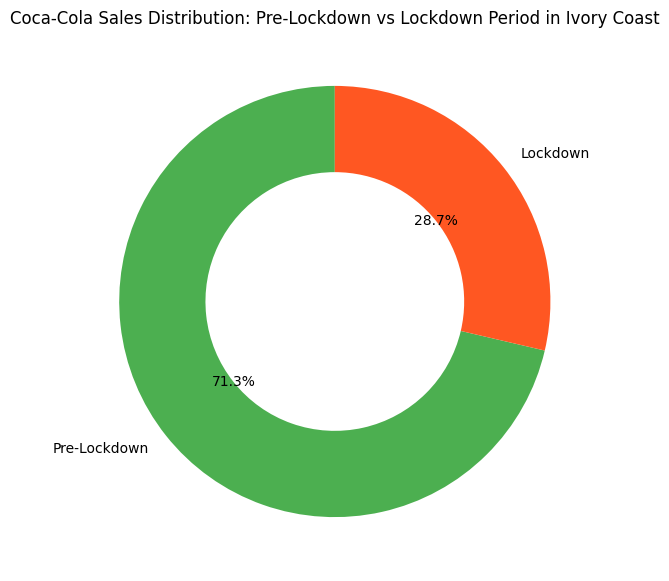

In [35]:
total_sales_pre_lockdown = pre_lockdown_period['units_sold'].sum()
total_sales_lockdown = lockdown_period['units_sold'].sum()

values = [total_sales_pre_lockdown, total_sales_lockdown]
labels = ['Pre-Lockdown', 'Lockdown']

plt.figure(figsize=(7,7))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'],
        startangle=90, wedgeprops={'width':0.4})
plt.title('Coca-Cola Sales Distribution: Pre-Lockdown vs Lockdown Period in Ivory Coast')
plt.show()


## What would sales have been without Covid 19 ?

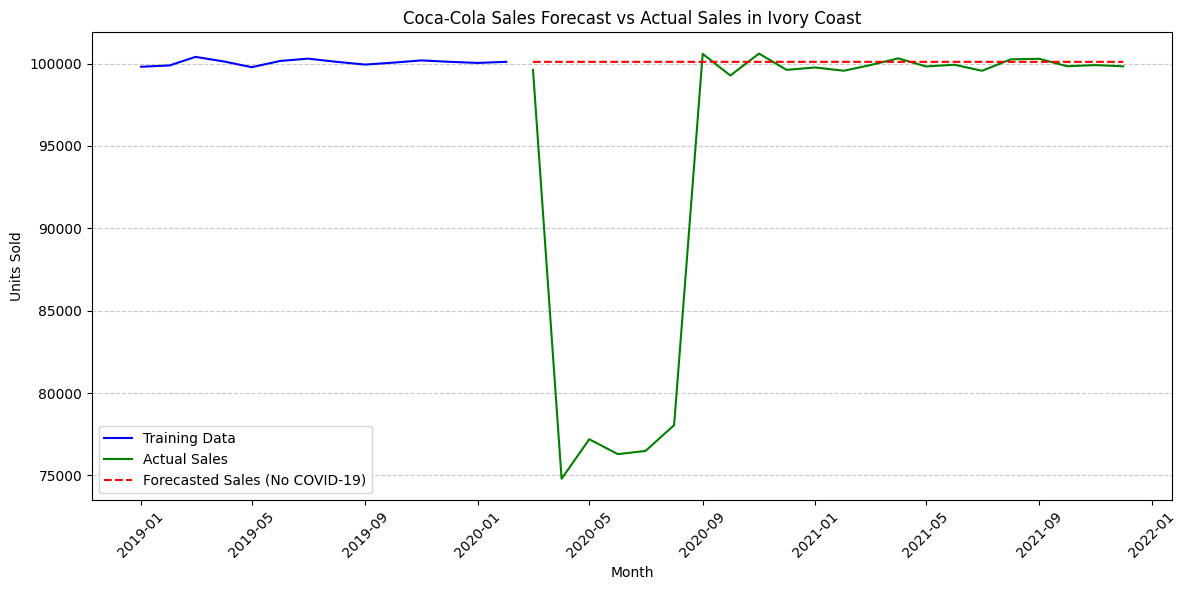

In [36]:
# Train and test the SARIMA model
# SARIMA model or Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors is predict future values by analyzing historical data and accounts for trends,#
# seasonality, and the influence of other external factors,
# # making it more accurate than a standard ARIMA model for many real-world situations.
train_data = monthly_total_sales[monthly_total_sales['month'] < '2020-03-01']
test_data = monthly_total_sales[monthly_total_sales['month'] >= '2020-03-01']

# Fit theSARIMA model
model = SARIMAX(train_data['units_sold'], order=(1,1,1), seasonal_order=(0,0,0,0))
model_fit = model.fit(disp=False)
forecast = model_fit.forecast(steps=len(test_data))

# Plot the results
plt.figure(figsize=(12,6))
plt.plot(train_data['month'], train_data['units_sold'], label='Training Data', color='blue')
plt.plot(test_data['month'], test_data['units_sold'], label='Actual Sales', color='green')
plt.plot(test_data['month'], forecast, label='Forecasted Sales (No COVID-19)', color='red', linestyle='--')
plt.title('Coca-Cola Sales Forecast vs Actual Sales in Ivory Coast')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Health impact - Pre-lockdown vs Lockdown

In [37]:
# Load WHO and Country Health Indicators datasets
who_health_df = pd.read_csv('who_health_indicators.csv', parse_dates=['year'])
who_health_df = who_health_df[who_health_df['country'] == 'Côte d\'Ivoire']

country_health_df = pd.read_csv('country_health_indicators.csv')
country_health_df = country_health_df[country_health_df['Country_Region'] == 'Cote d\'Ivoire']


who_health_df.head()
country_health_df.head()

,Country_Region,first_1ConfirmedCases,first_1Fatalities,first_10ConfirmedCases,first_50ConfirmedCases,first_100ConfirmedCases,cases_growth,death_growth,Cardiovascular diseases (%),Cancers (%),...,total fertility rate,obesity - adult prevalence rate,school_shutdown_1case,school_shutdown_10case,school_shutdown_50case,school_shutdown_1death,FF_DayOfYear,case1_DayOfYear,case10_DayOfYear,case50_DayOfYear
41,Cote d'Ivoire,2020-03-11,2020-03-29,2020-03-21,2020-03-24,2020-03-27,0.133304,0.0,5.665503,2.446825,...,3.67,10.3,6.0,-4.0,-7.0,-12.0,89.0,71,81.0,84.0


## Chart Pre-Lockdown vs Lockdown health indicators

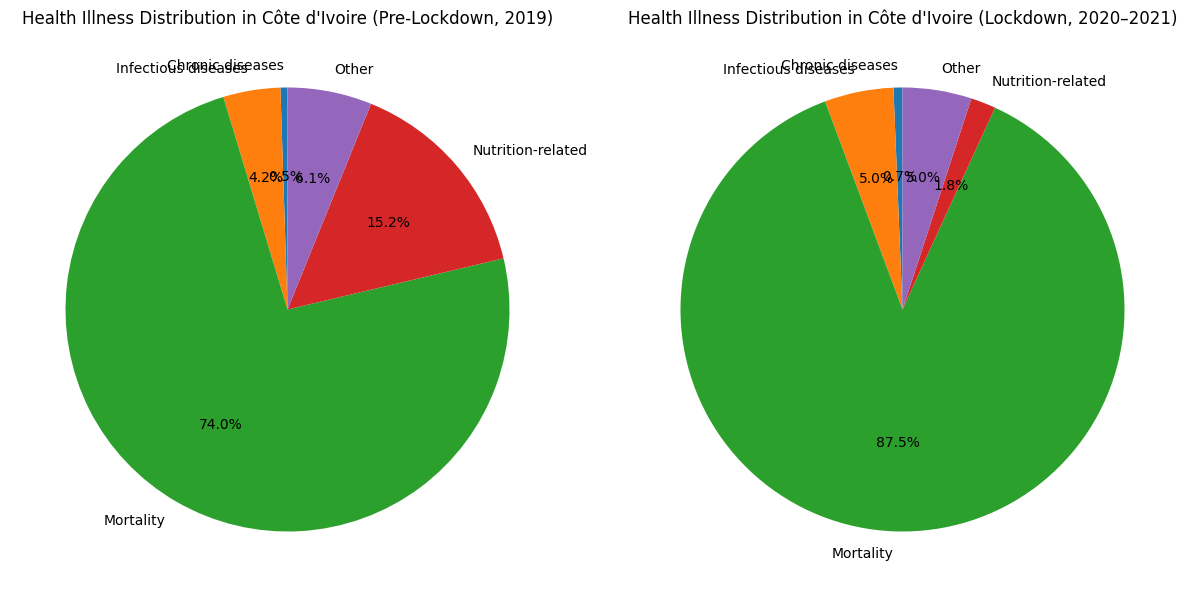

In [38]:
df = pd.read_csv("world_health_statistics_indicators_civ.csv")

# Clean numeric years
df = df[df["COUNTRY (DISPLAY)"] == "Côte d'Ivoire"].copy()
df = df[df["YEAR (DISPLAY)"].apply(lambda x: str(x).isdigit())]
df["YEAR (DISPLAY)"] = df["YEAR (DISPLAY)"].astype(int)

# Extract relevant columns
df = df[["GHO (DISPLAY)", "YEAR (DISPLAY)", "Value"]]

# Clean numeric values
df["Value"] = df["Value"].astype(str).str.extract(r"(\d+\.?\d*)").astype(float)

# Categorize illness types
def categorize_illness(name):
    name = name.lower()
    if "nutrition" in name or "stunting" in name or "wasting" in name:
        return "Nutrition-related"
    elif "hiv" in name or "malaria" in name or "tuberculosis" in name:
        return "Infectious diseases"
    elif "mortality" in name or "death" in name:
        return "Mortality"
    elif "ncd" in name or "bmi" in name or "obesity" in name:
        return "Chronic diseases"
    else:
        return "Other"

df["Category"] = df["GHO (DISPLAY)"].apply(categorize_illness)

# Split into time periods
pre_lockdown = df[df["YEAR (DISPLAY)"] == 2019]
lockdown = df[df["YEAR (DISPLAY)"].between(2020, 2021)]

# Group by category
pre_grouped = pre_lockdown.groupby("Category")["Value"].mean()
lock_grouped = lockdown.groupby("Category")["Value"].mean()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].pie(pre_grouped, labels=pre_grouped.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Health Illness Distribution in Côte d'Ivoire (Pre-Lockdown, 2019)")

axes[1].pie(lock_grouped, labels=lock_grouped.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Health Illness Distribution in Côte d'Ivoire (Lockdown, 2020–2021)")

plt.tight_layout()
plt.show()


📊 Percentage Change During Lockdown:
 Category
Chronic diseases       27.5
Infectious diseases    20.7
Mortality              18.2
Nutrition-related     -88.0
Other                 -18.2
Name: Value, dtype: float64


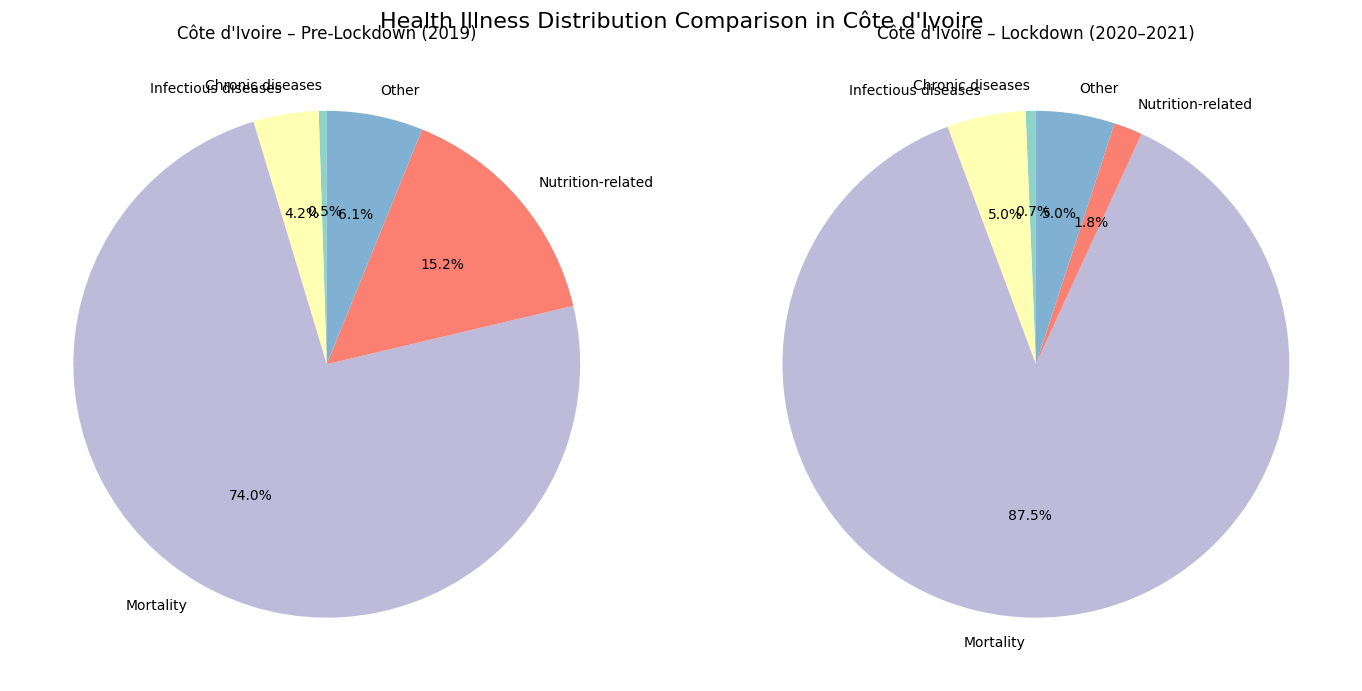

In [39]:
# --- Improved Health Impact Analysis ---

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("world_health_statistics_indicators_civ.csv")

# Filter for Côte d'Ivoire and clean numeric years
df = df[df["COUNTRY (DISPLAY)"] == "Côte d'Ivoire"].copy()
df = df[df["YEAR (DISPLAY)"].apply(lambda x: str(x).isdigit())]
df["YEAR (DISPLAY)"] = df["YEAR (DISPLAY)"].astype(int)

# Extract relevant columns
df = df[["GHO (DISPLAY)", "YEAR (DISPLAY)", "Value"]]

# Clean and convert numeric values safely
df["Value"] = pd.to_numeric(
    df["Value"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
    errors="coerce"
)
df = df.dropna(subset=["Value"])

# Categorize illness types
def categorize_illness(name):
    name = name.lower()
    if "nutrition" in name or "stunting" in name or "wasting" in name:
        return "Nutrition-related"
    elif "hiv" in name or "malaria" in name or "tuberculosis" in name:
        return "Infectious diseases"
    elif "mortality" in name or "death" in name:
        return "Mortality"
    elif "ncd" in name or "bmi" in name or "obesity" in name:
        return "Chronic diseases"
    else:
        return "Other"

df["Category"] = df["GHO (DISPLAY)"].apply(categorize_illness)

# Split into time periods
pre_lockdown = df[df["YEAR (DISPLAY)"] == 2019]
lockdown = df[df["YEAR (DISPLAY)"].between(2020, 2021)]

# Group by category and normalize to percentages
pre_grouped = pre_lockdown.groupby("Category")["Value"].mean()
lock_grouped = lockdown.groupby("Category")["Value"].mean()

# Ensure consistent categories
categories = sorted(set(pre_grouped.index) | set(lock_grouped.index))
pre_grouped = pre_grouped.reindex(categories, fill_value=0)
lock_grouped = lock_grouped.reindex(categories, fill_value=0)

# Normalize values to percentages
pre_grouped = pre_grouped / pre_grouped.sum() * 100
lock_grouped = lock_grouped / lock_grouped.sum() * 100

# Calculate percentage change
change = ((lock_grouped - pre_grouped) / pre_grouped * 100).round(1)
print("📊 Percentage Change During Lockdown:\n", change)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = plt.cm.Set3.colors

axes[0].pie(pre_grouped, labels=pre_grouped.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
axes[0].set_title("Côte d'Ivoire – Pre-Lockdown (2019)")

axes[1].pie(lock_grouped, labels=lock_grouped.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
axes[1].set_title("Côte d'Ivoire – Lockdown (2020–2021)")

plt.suptitle("Health Illness Distribution Comparison in Côte d'Ivoire", fontsize=16)
plt.tight_layout()
plt.show()
